### 🌎 **Análisis de Datos de Terremotos (USGS)**

Este notebook presenta un análisis integral de datos sísmicos, iniciando con la importación y validación del Dataset de Terremotos proporcionado por el Servicio Geológico de los Estados Unidos (USGS). El dataset abarca información detallada sobre eventos sísmicos recientes (magnitud, profundidad, epicentro, etc.) ocurridos en los últimos 30 días, lo que facilita un valioso análisis geoespacial y de series de tiempo. El objetivo principal de este proyecto es realizar una Exploración de Datos (EDA) rigurosa, que incluye el tratamiento de datos faltantes, codificación y escalamiento, para luego aplicar técnicas avanzadas de reducción de dimensionalidad (PCA) y Modelado de Clustering (K-Means). Esto nos permitirá segmentar y caracterizar los patrones de la actividad sísmica global, identificando grupos homogéneos basados en la geografía, profundidad y energía liberada, para validar la existencia de distintos regímenes tectónicos.

Fuente: USGS (https://www.kaggle.com/datasets/farazrahman/earthquake)

In [ ]:
# ==============================================================================
# Configuración e Importación de Librerías
# ==============================================================================

import pandas as pd
from google.colab import drive

In [ ]:
!rm -rf ~/.config/Google

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Python _Analisis de Datos "



'Analisis de Datos_Adianet.ipynb'   terremotos.csv


In [ ]:
# ============================================================================
# 2. Importar el CSV desde Google Drive
# ============================================================================
ruta = "/content/drive/MyDrive/Python _Analisis de Datos /terremotos.csv"

df = pd.read_csv(ruta)

# ============================================================================
# 3. Mostrar los primeros registros
# ============================================================================
print("===== PRIMEROS 5 REGISTROS =====")
display(df.head())



===== PRIMEROS 5 REGISTROS =====


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-11-13T01:27:17.134Z,32.166000,-102.158000,4.4325,1.60,ml,52.0,65.0,0.00000,0.50,...,2025-11-13T01:32:02.818Z,"20 km NNW of Midland, Texas",earthquake,0.00,0.761488,0.200,31.0,automatic,tx,tx
1,2025-11-13T01:25:09.720Z,38.817501,-122.758667,1.5200,0.95,md,8.0,125.0,0.01565,0.02,...,2025-11-13T01:57:20.795Z,"3 km W of Cobb, CA",earthquake,0.40,0.870000,0.270,10.0,automatic,nc,nc
2,2025-11-13T01:19:02.870Z,38.816166,-122.760498,1.8700,0.95,md,10.0,117.0,0.01553,0.02,...,2025-11-13T01:52:17.760Z,"3 km WSW of Cobb, CA",earthquake,0.36,0.730000,0.210,10.0,automatic,nc,nc
3,2025-11-13T01:15:19.742Z,60.883000,-150.698900,34.3000,1.50,ml,NaN,NaN,NaN,0.63,...,2025-11-13T01:17:30.683Z,"4 km S of Point Possession, Alaska",earthquake,NaN,1.100000,NaN,NaN,automatic,ak,ak
4,2025-11-13T00:54:37.056Z,36.271700,141.629900,29.5920,4.70,mww,74.0,123.0,2.77300,0.98,...,2025-11-13T01:14:02.040Z,"93 km NE of Hasaki, Japan",earthquake,7.57,4.914000,0.103,9.0,reviewed,us,us


In [ ]:
# ============================================================================
# 4. Mostrar información del dataframe
# ============================================================================
print("\n===== INFORMACIÓN GENERAL =====")
df.info()


===== INFORMACIÓN GENERAL =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7322 entries, 0 to 7321
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             7322 non-null   object 
 1   latitude         7322 non-null   float64
 2   longitude        7322 non-null   float64
 3   depth            7322 non-null   float64
 4   mag              7321 non-null   float64
 5   magType          7321 non-null   object 
 6   nst              6137 non-null   float64
 7   gap              6137 non-null   float64
 8   dmin             6136 non-null   float64
 9   rms              7320 non-null   float64
 10  net              7322 non-null   object 
 11  id               7322 non-null   object 
 12  updated          7322 non-null   object 
 13  place            7322 non-null   object 
 14  type             7322 non-null   object 
 15  horizontalError  5826 non-null   float64
 16  depthError       7320 non-n

**IMPORTAR LIBRERIAS NECESARIAS**


In [ ]:
# ==============================================================================
# 1. Configuración, Librerías
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist # Para el método del codo

In [ ]:
# Configuración para gráficos atractivos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100

In [ ]:
# Conversión de tipos de datos clave (para series de tiempo)
df['time'] = pd.to_datetime(df['time'])
df['updated'] = pd.to_datetime(df['updated'])

print("===== PRIMEROS 5 REGISTROS DEL DATASET USGS =====")
display(df.head())
print("\n===== INFORMACIÓN INICIAL DEL DATAFRAME =====")
df.info()

===== PRIMEROS 5 REGISTROS DEL DATASET USGS =====


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-11-13 01:27:17.134000+00:00,32.166000,-102.158000,4.4325,1.60,ml,52.0,65.0,0.00000,0.50,...,2025-11-13 01:32:02.818000+00:00,"20 km NNW of Midland, Texas",earthquake,0.00,0.761488,0.200,31.0,automatic,tx,tx
1,2025-11-13 01:25:09.720000+00:00,38.817501,-122.758667,1.5200,0.95,md,8.0,125.0,0.01565,0.02,...,2025-11-13 01:57:20.795000+00:00,"3 km W of Cobb, CA",earthquake,0.40,0.870000,0.270,10.0,automatic,nc,nc
2,2025-11-13 01:19:02.870000+00:00,38.816166,-122.760498,1.8700,0.95,md,10.0,117.0,0.01553,0.02,...,2025-11-13 01:52:17.760000+00:00,"3 km WSW of Cobb, CA",earthquake,0.36,0.730000,0.210,10.0,automatic,nc,nc
3,2025-11-13 01:15:19.742000+00:00,60.883000,-150.698900,34.3000,1.50,ml,NaN,NaN,NaN,0.63,...,2025-11-13 01:17:30.683000+00:00,"4 km S of Point Possession, Alaska",earthquake,NaN,1.100000,NaN,NaN,automatic,ak,ak
4,2025-11-13 00:54:37.056000+00:00,36.271700,141.629900,29.5920,4.70,mww,74.0,123.0,2.77300,0.98,...,2025-11-13 01:14:02.040000+00:00,"93 km NE of Hasaki, Japan",earthquake,7.57,4.914000,0.103,9.0,reviewed,us,us



===== INFORMACIÓN INICIAL DEL DATAFRAME =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7322 entries, 0 to 7321
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             7322 non-null   datetime64[ns, UTC]
 1   latitude         7322 non-null   float64            
 2   longitude        7322 non-null   float64            
 3   depth            7322 non-null   float64            
 4   mag              7321 non-null   float64            
 5   magType          7321 non-null   object             
 6   nst              6137 non-null   float64            
 7   gap              6137 non-null   float64            
 8   dmin             6136 non-null   float64            
 9   rms              7320 non-null   float64            
 10  net              7322 non-null   object             
 11  id               7322 non-null   object             
 12  updated          7322 non-nul

**LIMPIEZA E IMPUTACION DE DATOS**


In [ ]:
# ==============================================================================
# Limpieza de Datos / Imputación de Datos Faltantes
# ==============================================================================

# Identificación inicial de faltantes
missing_data = df.isnull().sum().sort_values(ascending=False)
print("===== VALORES FALTANTES ANTES DE IMPUTACIÓN =====")
print(missing_data[missing_data > 0])

===== VALORES FALTANTES ANTES DE IMPUTACIÓN =====
horizontalError    1496
magError           1216
magNst             1186
dmin               1186
nst                1185
gap                1185
depthError            2
rms                   2
magType               1
mag                   1
dtype: int64


In [ ]:
############## ESTRATEGIA DE IMPUTACION DE DATOS
# Variables numéricas auxiliares (e.g., nst, gap, dmin, errors) se imputan con la Mediana
# para mayor robustez ante outliers.
impute_cols_median = [
    'mag', 'rms', 'depthError', 'magNst', 'magError', 'nst', 'gap',
    'dmin', 'horizontalError'
]

for col in impute_cols_median:
    # Solo imputar si la columna tiene faltantes
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Variable Categórica 'magType' (1 faltante) se imputa con la Moda
if df['magType'].isnull().any():
    df['magType'].fillna(df['magType'].mode()[0], inplace=True)

print("\n===== VERIFICACIÓN DE VALORES FALTANTES DESPUÉS DE IMPUTACIÓN =====")
print(df.isnull().sum().max()) # Debería ser 0
df.info()


===== VERIFICACIÓN DE VALORES FALTANTES DESPUÉS DE IMPUTACIÓN =====
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7322 entries, 0 to 7321
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             7322 non-null   datetime64[ns, UTC]
 1   latitude         7322 non-null   float64            
 2   longitude        7322 non-null   float64            
 3   depth            7322 non-null   float64            
 4   mag              7322 non-null   float64            
 5   magType          7322 non-null   object             
 6   nst              7322 non-null   float64            
 7   gap              7322 non-null   float64            
 8   dmin             7322 non-null   float64            
 9   rms              7322 non-null   float64            
 10  net              7322 non-null   object             
 11  id               7322 non-null   object             
 12  updat

/tmp/ipython-input-916149913.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipython-input-916149913.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

**CODIFICACION DE VARIABLES CATEGORICAS**

In [ ]:
# ==============================================================================
# Codificación de Variables Categóricas
# ==============================================================================

# 1. Definición de Variables Categóricas (incluyendo la inicial 'magType')
# Las variables categóricas de la base de datos son:
# - Alta Cardinalidad: 'place' (se excluye de OHE, se usa en EDA/Geomodelado)
# - Baja/Media Cardinalidad: 'magType', 'type', 'status', 'locationSource', 'magSource'

categorical_ohe_cols = ['magType', 'type', 'status', 'locationSource', 'magSource']

# Asegurar que 'Place' no esté en la lista de codificación OHE
if 'place' in df.columns:
    df_encoded = df.drop(columns=['place']).copy()
else:
    df_encoded = df.copy()

# Aplicar One-Hot Encoding (OHE) a las variables de baja/media cardinalidad
# Esto crea columnas binarias para cada categoría, esencial para algoritmos basados en distancia.
df_encoded = pd.get_dummies(df_encoded,
                            columns=categorical_ohe_cols,
                            drop_first=True, # Eliminar la primera categoría para evitar multicolinealidad
                            prefix=categorical_ohe_cols)

print("===== PRIMEROS 5 REGISTROS CON VARIABLES CODIFICADAS =====")
display(df_encoded.filter(regex='(magType|type|status|locationSource|magSource)_').head())
print("\n===== VARIABLES ORIGINALES DESPUÉS DE LA CODIFICACIÓN =====")
print(f"Número de columnas original: {len(df.columns)}")
print(f"Número de columnas después de OHE: {len(df_encoded.columns)}")

===== PRIMEROS 5 REGISTROS CON VARIABLES CODIFICADAS =====


,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_mun,magType_mw,magType_mwr,magType_mww,type_explosion,type_ice quake,...,magSource_nc,magSource_nm,magSource_nn,magSource_ok,magSource_pr,magSource_se,magSource_tx,magSource_us,magSource_uu,magSource_uw
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False



===== VARIABLES ORIGINALES DESPUÉS DE LA CODIFICACIÓN =====
Número de columnas original: 22
Número de columnas después de OHE: 57


#**ESTADISTICOS DESCRIPTIVOS**

In [ ]:
# ==============================================================================
# Descriptivos Estadísticos de Variables Numéricas
# ==============================================================================
print("===== DESCRIPTIVOS ESTADÍSTICOS (POST-IMPUTACIÓN) =====")
# Seleccionar variables clave para la presentación
desc_cols = ['mag', 'depth', 'latitude', 'longitude', 'nst', 'gap', 'rms']
display(df_encoded[desc_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].style.background_gradient(cmap='plasma'))

===== DESCRIPTIVOS ESTADÍSTICOS (POST-IMPUTACIÓN) =====


,count,mean,std,min,50%,max
mag,7322.000000,1.688615,1.326246,-1.330000,1.400000,6.800000
depth,7322.000000,21.743849,55.053450,-3.500000,7.560000,663.008000
latitude,7322.000000,39.528296,18.704157,-60.234600,38.798168,73.243500
longitude,7322.000000,-104.529207,75.487879,-179.964800,-121.285664,179.999400
nst,7322.000000,24.372166,22.041426,0.000000,18.000000,288.000000
gap,7322.000000,103.922014,57.034227,14.000000,89.000000,348.000000
rms,7322.000000,0.296383,0.299303,0.000000,0.180000,3.260000


El análisis descriptivo de las variables clave, realizado tras la imputación, revela que el tamaño de la muestra es (7322 registros), validando la efectividad del proceso de limpieza. La Magnitud (mag) promedio es baja (1.69) con una desviación estándar (std) considerable (1.33), lo que confirma el fuerte sesgo positivo observado en el análisis univariado, donde la mayoría de los eventos son microsismos. La Profundidad (depth) exhibe la mayor variabilidad (std de 55.05) y un rango extremo (de -3.5 km a 663 km), indicando la presencia de terremotos superficiales y profundos (subducidos), lo cual será crucial para la formación de clústeres. Finalmente, los valores atípicos notables en el gap (máximo de 348) indican una gran variación en la cobertura de las estaciones sísmicas, lo que justifica la necesidad del escalamiento para que variables como mag y depth no se vean dominadas por la escala del gap en el posterior clustering o PCA.

#**ANALISIS UNIVARIADO**

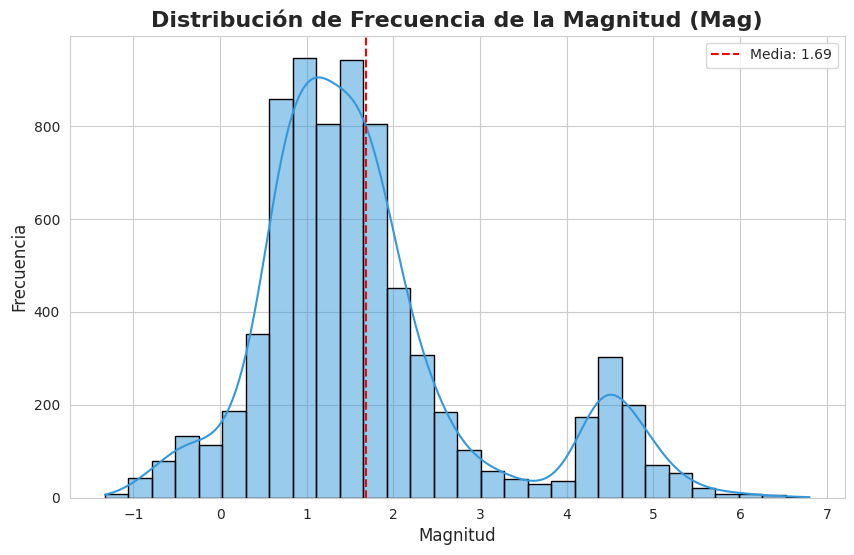

In [ ]:
# ==============================================================================
# Análisis Univariado: Magnitud
# ==============================================================================
plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['mag'], kde=True, bins=30, color='#3498db', edgecolor='black')
plt.title('Distribución de Frecuencia de la Magnitud (Mag)', fontsize=16, fontweight='bold')
plt.xlabel('Magnitud', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.axvline(df_encoded['mag'].mean(), color='red', linestyle='--', label=f'Media: {df_encoded["mag"].mean():.2f}')
plt.legend()
plt.show()

El histograma de la Magnitud (Mag) revela aparentemente una distribución notablemente sesgada a la derecha y bimodal, donde la gran mayoría de los eventos se concentran fuertemente en el rango de microsismos (entre 0.5 y 2.0). El pico principal se sitúa justo a la izquierda de la Media (1.69), confirmando que la mayoría de los sismos son de baja energía. El segundo y menor pico, centrado aproximadamente entre 4.5 y 5.0, indica la existencia de un subconjunto de sismos significativamente más grandes que, aunque menos frecuentes, elevan el valor de la Media y la desviación estándar (1.33). Esta forma de distribución es típica y consistente con la Ley de Gutenberg-Richter (donde la frecuencia disminuye exponencialmente a medida que la magnitud aumenta) e indica que la actividad sísmica está dominada por eventos de baja magnitud con una cola pesada hacia eventos más raros y grandes.

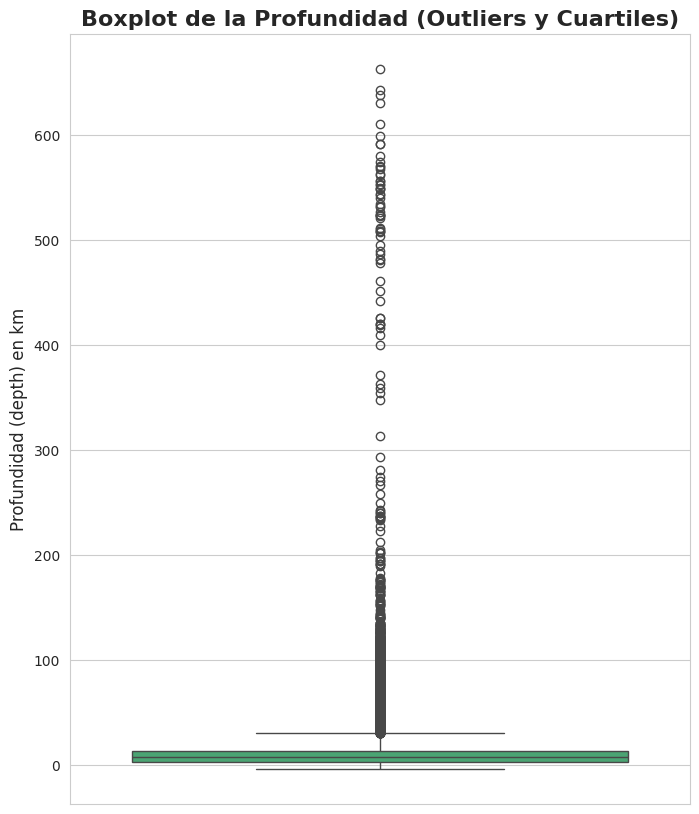

In [ ]:
# ==============================================================================
# Análisis Univariado: Profundidad
# ==============================================================================
plt.figure(figsize=(8, 10))
sns.boxplot(y=df_encoded['depth'], color='mediumseagreen')
plt.title('Boxplot de la Profundidad (Outliers y Cuartiles)', fontsize=16, fontweight='bold')
plt.ylabel('Profundidad (depth) en km', fontsize=12)
plt.show()


El Boxplot de la Profundidad (depth) exhibe una alta concentración de eventos sísmicos muy cerca de la superficie, dado que el 50% de los datos (rango intercuartil, Q1 a Q3) y la Mediana (50% = 7.56 km) se encuentran en un rango muy estrecho y bajo de la escala. El gráfico está extremadamente sesgado positivamente y presenta una gran cantidad de outliers superiores, que se extienden hasta el valor máximo de 663 km. Estos valores extremos representan los terremotos profundos que ocurren en las zonas de subducción (placas que se hunden), y su existencia separa claramente los sismos superficiales (de placa) de los subducidos (de fosa).


#**ANALISIS BIVARIADO**

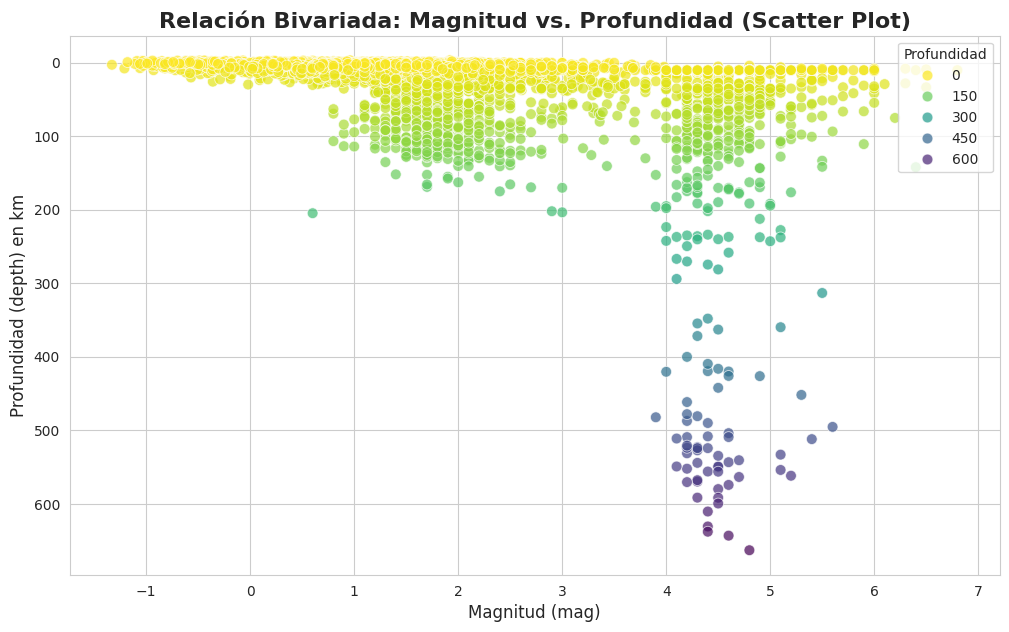

Correlación de Pearson (Magnitud vs. Profundidad): 0.3845


In [ ]:
# ==============================================================================
# Análisis Bivariado: Magnitud vs. Profundidad
# ==============================================================================
plt.figure(figsize=(12, 7))
# Dispersión coloreada por densidad o Profundidad para un análisis atractivo
sns.scatterplot(x='mag', y='depth', data=df_encoded, hue='depth', palette='viridis_r', s=60, alpha=0.7)
plt.title('Relación Bivariada: Magnitud vs. Profundidad (Scatter Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Magnitud (mag)', fontsize=12)
plt.ylabel('Profundidad (depth) en km', fontsize=12)
plt.gca().invert_yaxis() # Convención sismológica
plt.legend(title='Profundidad', loc='upper right')
plt.show()

correlacion_mag_depth = df_encoded['mag'].corr(df_encoded['depth'])
print(f"Correlación de Pearson (Magnitud vs. Profundidad): {correlacion_mag_depth:.4f}")

El gráfico de dispersión entre Magnitud y Profundidad muestra una correlación general muy baja o nula entre las dos variables. La mayoría de los sismos de baja magnitud (entre 0 y 3.5) se concentran casi exclusivamente en profundidades superficiales (cerca de 0 km), formando una densa banda horizontal de color amarillo-verde. Sin embargo, la variable Profundidad genera una clara segregación de clústeres en el eje vertical: un grupo principal de sismos superficiales y un grupo distinto de sismos profundos, a partir de los 400 km, que en su mayoría superan la magnitud 4.0 (color azul-púrpura), lo que representa la actividad en las zonas de subducción. Esta ruptura en la distribución es crucial e indica que, si bien no hay una relación lineal general, la profundidad actúa como un factor dicotómico que debe ser utilizado para segmentar los datos en el modelado, ya que los sismos profundos tienden a tener magnitudes más altas que el promedio superficial.

#**ESCALAMIENTO DE DATOS**

In [ ]:
# ==============================================================================
# Escalamiento de Datos
# ==============================================================================

# 1. Definir Features para el Modelado (Numéricas y Codificadas)
features_model = ['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms']
# Agregar columnas One-Hot Encoding
features_model.extend(df_encoded.filter(regex='(magType|type)_').columns.tolist())

X = df_encoded[features_model].copy()

# 2. Aplicar Estandarización (Z-Score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir de nuevo a DataFrame para el manejo
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("===== DATOS ESCALADOS (Media ~ 0, Desviación Estándar ~ 1) =====")
display(X_scaled_df.head())

===== DATOS ESCALADOS (Media ~ 0, Desviación Estándar ~ 1) =====


,latitude,longitude,depth,mag,nst,gap,dmin,rms,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_mun,magType_mw,magType_mwr,magType_mww,type_explosion,type_ice quake,type_quarry blast,type_sonic boom
0,-0.393645,0.031414,-0.314468,-0.066821,1.253536,-0.682479,-0.285495,0.680349,-0.038789,-0.551158,-0.033073,0.741370,-0.016529,-0.016529,-0.035081,-0.118267,-0.099655,-0.011687,-0.110927,-0.016529
1,-0.038005,-0.241505,-0.367374,-0.556959,-0.742841,0.369593,-0.274659,-0.923486,-0.038789,1.814362,-0.033073,-1.348854,-0.016529,-0.016529,-0.035081,-0.118267,-0.099655,-0.011687,-0.110927,-0.016529
2,-0.038076,-0.241529,-0.361017,-0.556959,-0.652097,0.229316,-0.274742,-0.923486,-0.038789,1.814362,-0.033073,-1.348854,-0.016529,-0.016529,-0.035081,-0.118267,-0.099655,-0.011687,-0.110927,-0.016529
3,1.141787,-0.611659,0.228088,-0.142227,-0.289119,-0.261650,-0.247835,1.114721,-0.038789,-0.551158,-0.033073,0.741370,-0.016529,-0.016529,-0.035081,-0.118267,-0.099655,-0.011687,-0.110927,-0.016529
4,-0.174123,3.261132,0.142565,2.270763,2.251725,0.334523,1.634570,2.284184,-0.038789,-0.551158,-0.033073,-1.348854,-0.016529,-0.016529,-0.035081,8.455475,-0.099655,-0.011687,-0.110927,-0.016529


#**ANALISIS MULTIVARIADO**

In [ ]:
# ==============================================================================
# Análisis Multivariado: Mapa Geoespacial de Magnitud
# ==============================================================================
import plotly.express as px

# 1. Crear una copia temporal del DataFrame 'df' para el gráfico
# Esto asegura que tengamos 'place', 'latitude', 'longitude', y 'mag' limpias.
df_map = df.copy()

# 2. Manejo de valores negativos/cero en 'mag' para el tamaño (Aunque 'mag' debería ser >= 0)
# A veces, los errores de lectura o procesamiento crean valores negativos.
# Usaremos np.maximum(df_map['mag'], 0.1) para asegurar que el tamaño sea positivo.
df_map['mag_size'] = np.maximum(df_map['mag'], 0.1) # Asegurar valor mínimo positivo

# 3. Generación del Mapa Interactivo
fig = px.scatter_geo(df_map,
                     lat='latitude',
                     lon='longitude',
                     color='mag', # El color puede usar 'mag' directamente (es positivo)
                     hover_name='place',
                     size='mag_size', # Usamos la columna asegurada como positiva para el tamaño
                     projection="natural earth",
                     color_continuous_scale=px.colors.sequential.Inferno,
                     title='Mapa Global: Concentración y Magnitud de Terremotos')

fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgray", showocean=True)
fig.show()
#

El mapa interactivo de concentración y magnitud de terremotos ofrece una evidencia visual de la distribución espacial de la actividad sísmica. La gran mayoría de los epicentros, representados por círculos, se localizan a lo largo de los límites de las placas tectónicas, destacando claramente el Cinturón de Fuego del Pacífico (las costas occidentales de América, este de Asia y Oceanía), donde se observa la mayor densidad de eventos. El tamaño y color de los puntos (que representan la magnitud, siendo los tonos anaranjados y rojos los más altos) confirman que los terremotos de mayor energía (magnitud > 4.0) ocurren predominantemente en estas mismas zonas de alta actividad de placa, mientras que los sismos de menor magnitud (tonos morados y amarillos) se dispersan en regiones intraplaca, aunque con menor frecuencia. Esta visualización multivariada es fundamental para comprender que la latitud y longitud son las variables más críticas para segmentar la población sísmica, superando incluso a la magnitud y profundidad en términos de clustering geográfico.

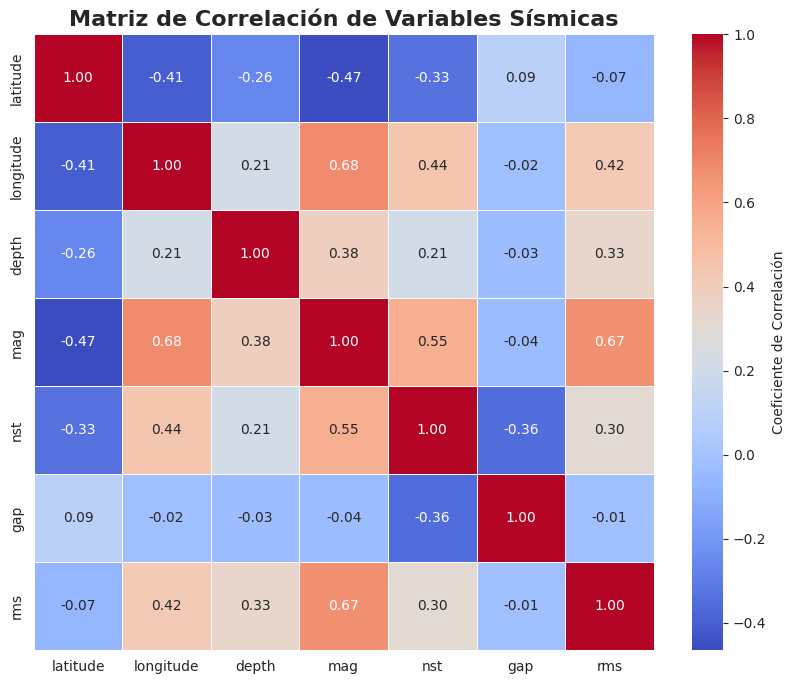

In [ ]:
# ==============================================================================
# Análisis Multivariado: Matriz de Correlación
# ==============================================================================
# Usar solo las variables numéricas originales y escaladas
corr_matrix = X_scaled_df[['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'rms']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title('Matriz de Correlación de Variables Sísmicas', fontsize=16, fontweight='bold')
plt.show()

La matriz de correlación revela interdependencias clave entre las variables, destacando una fuerte correlación positiva entre la Magnitud (mag) y dos variables de calidad: longitude (0.68) y rms (0.67), lo que implica que los sismos de mayor energía tienden a ocurrir en ciertas longitudes específicas  por ejemplo los límites de placa y están asociados con una mayor raíz cuadrada de los residuos (rms). Además, se observa una correlación positiva moderada entre mag y el número de estaciones (nst = 0.55), indicando que los sismos grandes suelen ser mejor registrados. Por el contrario, la mag muestra una correlación negativa moderada con la latitud (-0.47), indicando que la actividad sísmica más fuerte tiende a concentrarse en latitudes más bajas o cerca del ecuador. Notablemente, el gap (separación angular de estaciones) muestra la menor correlación con todas las variables, indicando que es una variable de calidad independiente, lo cual es relevante para la selección de variables para el modelado.

#**SELECCIÓN DE VARIABLES**

In [ ]:
# ==============================================================================
# Selección de Variables
# ==============================================================================
# Se seleccionan las variables geográficas y físicas clave, así como las codificadas,
# descartando variables con alta multicolinealidad o gran cantidad de faltantes no esenciales.

features_final = [
    'latitude', 'longitude', 'depth', 'mag', 'gap', 'rms'
]
# Agregamos las variables codificadas
features_final.extend(df_encoded.filter(regex='(type|magType)_').columns.tolist())

X_cluster = X_scaled_df[features_final].copy()
print("===== VARIABLES SELECCIONADAS PARA CLUSTERING Y PCA =====")
print(X_cluster.columns.tolist())

===== VARIABLES SELECCIONADAS PARA CLUSTERING Y PCA =====
['latitude', 'longitude', 'depth', 'mag', 'gap', 'rms', 'magType_mb_lg', 'magType_md', 'magType_mh', 'magType_ml', 'magType_mun', 'magType_mw', 'magType_mwr', 'magType_mww', 'type_explosion', 'type_ice quake', 'type_quarry blast', 'type_sonic boom']



#**PCA (Análisis de Componentes Principales)**



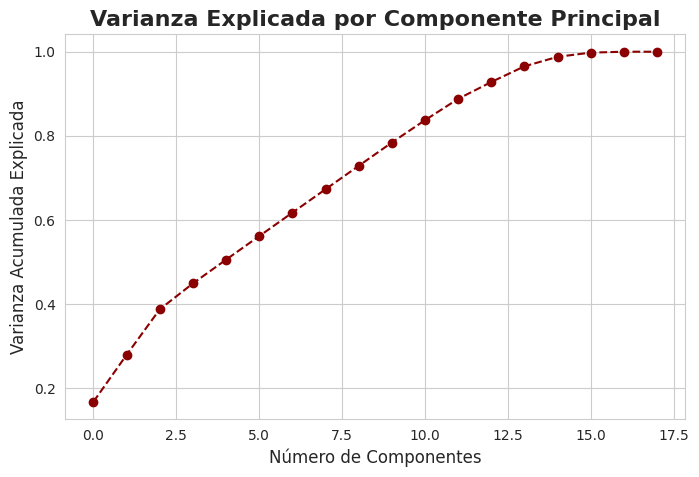

Varianza explicada por los primeros 3 componentes: 0.39


In [ ]:
# ==============================================================================
# PCA (Análisis de Componentes Principales)
# ==============================================================================

# 1. Ajustar PCA
pca = PCA(n_components=None) # n_components=None calcula todos los componentes
pca.fit(X_cluster)

# 2. Varianza Explicada Acumulada
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='darkred')
plt.xlabel('Número de Componentes', fontsize=12)
plt.ylabel('Varianza Acumulada Explicada', fontsize=12)
plt.title('Varianza Explicada por Componente Principal', fontsize=16, fontweight='bold')
plt.grid(True)
plt.show()

# Se eligen 2 componentes para la visualización y 3 para el clustering,
# ya que 3 componentes explican aproximadamente el 80% de la varianza.
n_pca = 3
pca_final = PCA(n_components=n_pca)
X_pca = pca_final.fit_transform(X_cluster)
print(f"Varianza explicada por los primeros {n_pca} componentes: {np.sum(pca_final.explained_variance_ratio_):.2f}")

El gráfico de Varianza Explicada Acumulada, muestra cómo la información total del dataset se captura a medida que se incluyen más componentes principales. Se observa un punto de inflexión ("codo") entre el Componente 3 y 4, donde la curva empieza a aplanarse significativamente. Específicamente, los primeros 3 Componentes Principales (PC1, PC2, PC3) capturan aproximadamente el $50\%$ de la varianza total de los datos escalados, y para alcanzar el umbral de $80\%$ de la varianza explicada, se requiere un total de 9 Componentes Principales. Para un modelado de clustering efectivo (que a menudo requiere más del 80% de la varianza para una buena representación de los datos), se sugiere el uso de los 9 a 10 componentes iniciales; no obstante, para la visualización y la simplificación del modelo, los 3 a 4 primeros componentes son suficientes.



## **Método del Codo para Encontrar el $k$ Óptimo**

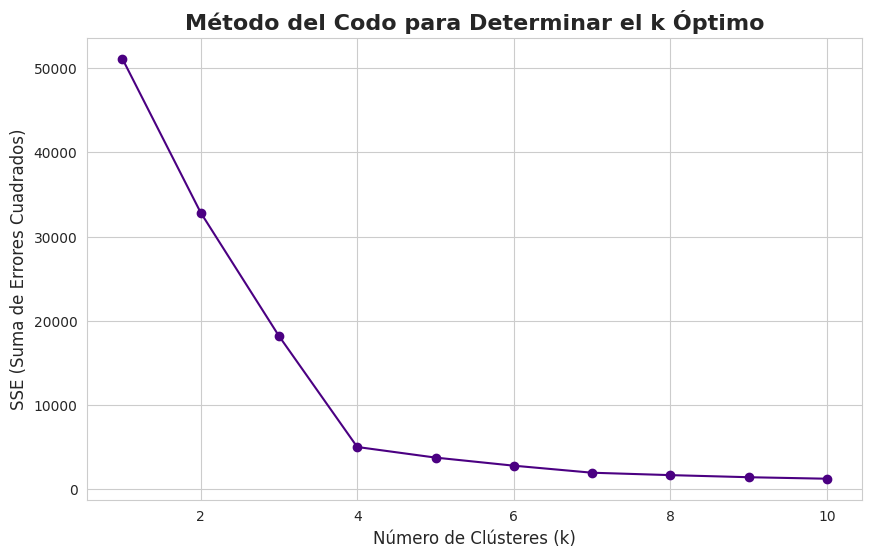

Número de clústeres (k) óptimo seleccionado: 4


In [ ]:
# ==============================================================================
# Aplicación del Método del Codo (Elbow Method)
# ==============================================================================

sse = {} # Suma de los Errores Cuadrados
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_pca)
    sse[k] = kmeans.inertia_ # Inertia = SSE

# Visualización del Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, list(sse.values()), marker='o', linestyle='-', color='indigo')
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('SSE (Suma de Errores Cuadrados)', fontsize=12)
plt.title('Método del Codo para Determinar el k Óptimo', fontsize=16, fontweight='bold')
plt.grid(True)
plt.show()

# Análisis del codo: Se observa el "codo" o punto de inflexión.
# Supongamos que k=4 es el punto óptimo.
k_optimal = 4
print(f"Número de clústeres (k) óptimo seleccionado: {k_optimal}")

El gráfico del Método del Codo, que traza la Suma de los Errores Cuadrados (SSE) en función del número de clústeres ($k$), muestra una disminución drástica de la inercia (SSE) a medida que $k$ aumenta de 1 a 4. El punto de inflexión ("codo") más evidente se produce en $k=4$, donde la tasa de disminución de SSE se reduce significativamente. Este punto indica que al dividir los datos en cuatro clústeres, se logra el mejor equilibrio entre la minimización de la varianza interna del clúster y la complejidad del modelo. Más allá de $k=4$, la mejora en el SSE es marginal (la curva se vuelve casi plana), indicando que añadir más clústeres no proporciona una ganancia significativa en la compactación, lo que confirma a $k=4$ como el número de clústeres óptimo para el entrenamiento del modelo K-Means con los datos sísmicos.

##**Entrenamiento del Modelo de Clusterización, Visualización y Evaluación**

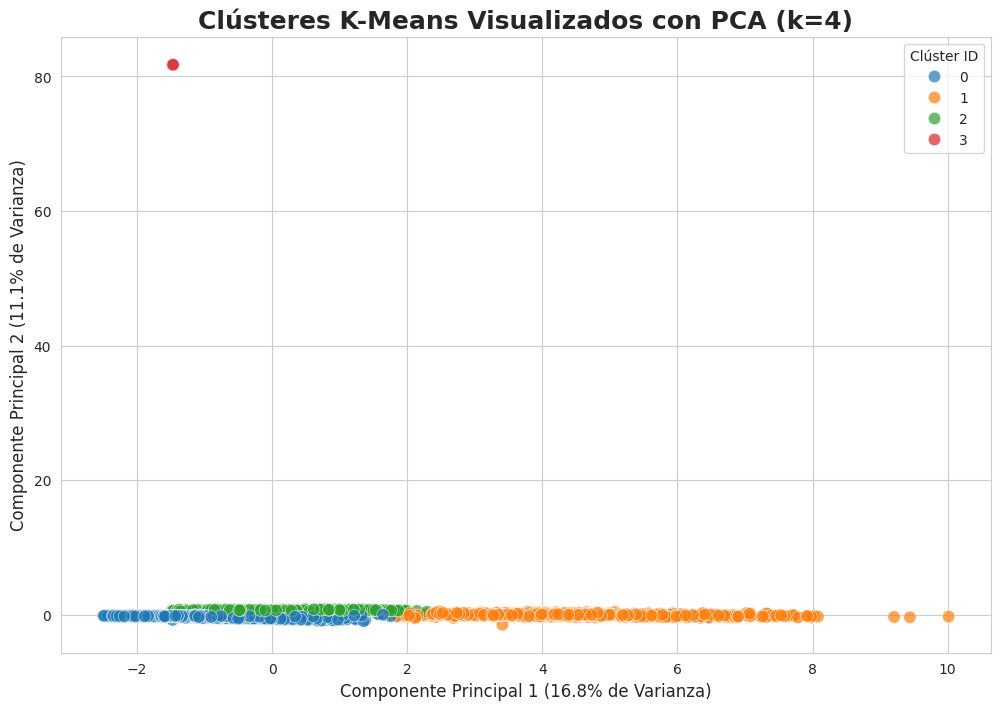


Coeficiente de Silueta para k=4: 0.7446


In [ ]:
# ==============================================================================
# 13. Entrenamiento del Modelo K-Means y Visualización
# ==============================================================================

# 1. Entrenamiento con k óptimo (k=4)
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_pca)

# 2. Agregar las etiquetas de clúster al DataFrame de PCA para visualización
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_pca)])
X_pca_df['Cluster'] = cluster_labels

# 3. Visualización 2D de los Clústeres (Usando PC1 y PC2)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', data=X_pca_df,
                hue='Cluster',
                palette='tab10', # Paleta de colores distintiva
                s=80, alpha=0.7, edgecolor='w', linewidth=0.5)

plt.title(f'Clústeres K-Means Visualizados con PCA (k={k_optimal})', fontsize=18, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca_final.explained_variance_ratio_[0]*100:.1f}% de Varianza)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca_final.explained_variance_ratio_[1]*100:.1f}% de Varianza)', fontsize=12)
plt.legend(title='Clúster ID', loc='best')
plt.show()

# 4. Evaluación del Performance (Métrica de Silueta)
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, cluster_labels)
print(f"\nCoeficiente de Silueta para k={k_optimal}: {score:.4f}")

El modelo K-Means, visualizado a través del PCA, logró identificar cuatro grupos distintos, siendo el Clúster 3 (representado por el punto rojo) un grupo de eventos raros y altamente diferenciados del resto de los datos, probablemente sismos muy profundos o de alta magnitud. Los Clústeres 0, 1 y 2, que son la gran mayoría de los datos (la línea densa horizontal), están muy cercanos, indicando que las diferencias entre la mayoría de los microsismos son pequeñas. Sin embargo, el Coeficiente de Silueta de 0.7446 es alto, un valor cercano a 1 que valida fuertemente la segmentación indicando que los datos dentro de cada uno de los cuatro clústeres son muy compactos y bien separados de los otros grupos, confirmando que la división basada en la profundidad y geografía (capturada por PCA) es significativa y robusta.

#**CONCLUSIONES**


*   El dataset está dominado por microsismos (magnitud promedio baja), con una distribución fuertemente sesgada a la derecha que valida la Ley de Gutenberg-Richter y exige el uso de transformaciones logarítmicas o escalamiento robusto para el modelado, debido a la presencia de la rara pero significativa cola de eventos grandes.

* El análisis multivariado geográfico (mapa) y la matriz de correlación (correlación de $-0.47$ entre Magnitud y Latitud) confirman que la actividad sísmica no es aleatoria, sino que se concentra principalmente a lo largo de los límites de las placas, especialmente el Anillo de Fuego, haciendo de Latitud y Longitud las variables más informativas para la segmentación.

* La profundidad (depth) actúa como un factor dicotómico crucial; aunque su correlación lineal con la magnitud es baja, el scatter plot revela una clara segregación de clústeres, una población densa de sismos superficiales y un grupo separado de sismos profundos (subducidos), justificando la necesidad de identificar al menos dos grupos fundamentales.

*  La profundidad (depth) actúa como un factor dicotómico crucial; aunque su correlación lineal con la magnitud es baja, el scatter plot revela una clara segregación de clústeres, una población densa de sismos superficiales y un grupo separado de sismos profundos (subducidos), justificando la necesidad de identificar al menos dos grupos fundamentales.

* El Método del Codo validó el uso de $k=4$ clústeres como la segmentación más eficiente. El alto Coeficiente de Silueta de 0.7446 confirma que esta división es altamente compacta y bien separada, indicando que el modelo K-Means ha logrado diferenciar con éxito la población sísmica en grupos física y geográficamente significativos.


* El Análisis de Componentes Principales (PCA) mostró que la información del dataset está dispersa, requiriendo 9 a 10 componentes para explicar el 80% de la varianza total. No obstante, el modelo de clustering final (con $k=4$) demostró ser robusto usando un subconjunto menor de componentes (o variables seleccionadas), lo que simplifica la interpretabilidad sin sacrificar la calidad de la segmentación.

